## ReLU MLP Single-Seed Learning Dynamics

This notebook runs a standard fully connected ReLU network with a single training phase.

It focuses on one seed to inspect learning dynamics clearly (checkpoints, scatter alignment, and start/end metrics).

No dropout, normalization, or multi-phase logic is used.

In [1]:
from pathlib import Path

from itables import show
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from layer_lenses.odt import samples_reaching_node
from layer_lenses.odt import odt_leaf_ids_for_x
from layer_lenses.relu_analysis import (
    collect_start_end_metrics,
    first_layer_odt_alignment,
    masked_accuracy_by_odt_leaf,
    neuron_leaf_responsibility_from_ablation,
    plot_first_layer_odt_alignment,
    plot_layered_relu_graph,
    quadratic_snapshot_epochs,
    run_single_relu_seed,
    summarize_neuron_responsibility,
)
from layer_lenses.relu_analysis import log_loss_gradients
from layer_lenses.relu_training import checkpoint_model_from_state
from layer_lenses.relu_analysis import activation_tensor_by_layer_neuron_data

from pathlib import Path
import pickle
from typing import Any

def save_seed_result_pickle(seed_result: dict[str, Any], path: str | Path) -> Path:
    """Save seed_result to a pickle file."""
    out_path = Path(path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("wb") as f:
        pickle.dump(seed_result, f, protocol=pickle.HIGHEST_PROTOCOL)
    return out_path


def load_seed_result_pickle(path: str | Path) -> dict[str, Any]:
    """Load seed_result from a pickle file."""
    in_path = Path(path)
    with in_path.open("rb") as f:
        obj = pickle.load(f)
    if not isinstance(obj, dict):
        raise TypeError(f"Expected dict from pickle, got {type(obj).__name__}")
    return obj



In [2]:


# Scratch-aligned defaults with a plain ReLU MLP.
DIM = 100
DEPTH = 5
N_TRAIN = 80_000
HIDDEN_DIMS = [40, 40, 40]

TOTAL_EPOCHS = 2000
LR = 2e-3
BATCH_SIZE = 80
WEIGHT_DECAY = 0.01

SNAPSHOT_EPOCHS = range(TOTAL_EPOCHS)
print(f"Using {len(SNAPSHOT_EPOCHS)} snapshot epochs.")

SEED = 6178

seed_result = None

Using 2000 snapshot epochs.


## Run selected seed

This is the expensive cell. It runs single-phase ReLU MLP training for the selected seed.

In [3]:
print(f"Running seed {SEED} ...")
seed_result = run_single_relu_seed(
    SEED,
    dim=DIM,
    depth=DEPTH,
    n_train=N_TRAIN,
    hidden_dims=HIDDEN_DIMS,
    total_epochs=TOTAL_EPOCHS,
    lr=LR,
    batch_size=BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    snapshot_epochs=SNAPSHOT_EPOCHS,
    project_first_layer_grad_orthogonal=None,
    odt_hyperplanes = "random_orthogonal",
    
)
print("Done")
tree =  seed_result["tree"]
ckpts = seed_result["out"]["checkpoint_snapshots"]

Running seed 6178 ...


Training ReLU MLP:   0%|          | 0/2001 [00:00<?, ?it/s]

Done


In [3]:
# Save
# save_path = save_seed_result_pickle(seed_result, "results/cache/seed_result_6178.pkl")
# print("Saved to:", save_path)

## Load
seed_result = load_seed_result_pickle("results/cache/seed_result_6178.pkl")
print(seed_result.keys())

tree =  seed_result["tree"]
ckpts = seed_result["out"]["checkpoint_snapshots"]

dict_keys(['master_seed', 'seeds', 'tree', 'meta', 'data', 'out'])


## First ODT capture epochs

For each ODT internal node, find the first checkpoint epoch where at least one first-layer ReLU neuron has absolute cosine alignment above a chosen threshold.

In [7]:
def first_odt_capture_epochs(
    ckpts: dict[int, dict[str, torch.Tensor]],
    tree,
    *,
    threshold: float = 0.8,
) -> pd.DataFrame:
    """Return first checkpoint where each ODT node is captured by a first-layer neuron.

    A node is captured when some first-layer neuron has ``abs(cosine) > threshold``
    with that node's ODT normal vector.
    """
    odt_wts = torch.from_numpy(tree.w_list).float()
    odt_norms = odt_wts.norm(dim=1).clamp_min(1e-12)
    hits_by_node = {node_id: None for node_id in range(tree.w_list.shape[0])}

    for epoch in sorted(ckpts.keys()):
        first_layer_wts = ckpts[epoch]["hidden_layers.0.weight"].detach().cpu().float()
        neuron_norms = first_layer_wts.norm(dim=1).clamp_min(1e-12)
        cos = (first_layer_wts @ odt_wts.T) / (neuron_norms[:, None] * odt_norms[None, :])
        abs_cos = cos.abs()

        for odt_node_id in range(tree.w_list.shape[0]):
            if hits_by_node[odt_node_id] is not None:
                continue

            neuron_scores = abs_cos[:, odt_node_id]
            best_neuron_id = int(torch.argmax(neuron_scores).item())
            best_abs_cos = float(neuron_scores[best_neuron_id].item())
            if best_abs_cos <= threshold:
                continue

            hits_by_node[odt_node_id] = {
                "odt_node_id": odt_node_id,
                "first_epoch": int(epoch),
                "first_layer_neuron_id": best_neuron_id,
                "cosine": float(cos[best_neuron_id, odt_node_id].item()),
                "abs_cosine": best_abs_cos,
                "threshold": float(threshold),
            }

        if all(hit is not None for hit in hits_by_node.values()):
            break

    rows = []
    for odt_node_id, hit in hits_by_node.items():
        if hit is None:
            rows.append(
                {
                    "odt_node_id": odt_node_id,
                    "first_epoch": np.nan,
                    "first_layer_neuron_id": np.nan,
                    "cosine": np.nan,
                    "abs_cosine": np.nan,
                    "threshold": float(threshold),
                }
            )
        else:
            rows.append(hit)

    return pd.DataFrame(rows).sort_values("odt_node_id", ignore_index=True)


odt_capture_epochs = first_odt_capture_epochs(
    ckpts,
    tree,
    threshold=0.8,
)
show(
    odt_capture_epochs,
    scrollY="500px",
    scrollX=True,
    search=True,
    paging=True,
    pageLength=32,
)

Loading ITables v2.7.3 from the internet... (need help?)


## ODT capture-epoch tree

Visualize the hierarchical order in which ODT internal nodes are first captured by first-layer ReLU neurons.

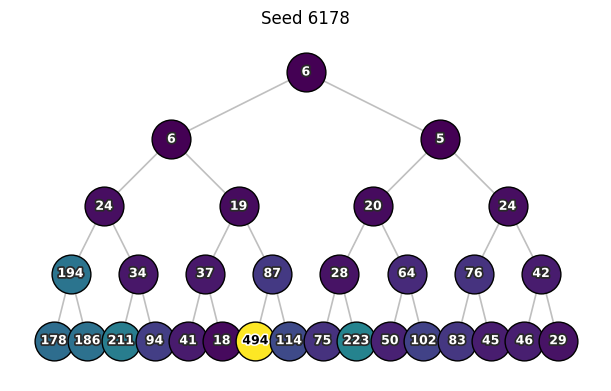

In [14]:
from layer_lenses.utilities import plot_complete_binary_tree_values

# Same data as `plot_odt_capture_epoch_tree`, as a breadth-order vector for the utility plotter
_n_relu_capture = int(odt_capture_epochs["odt_node_id"].max()) + 1
_capture_epoch_vec = (
    odt_capture_epochs.set_index("odt_node_id")["first_epoch"]
    .reindex(range(_n_relu_capture))
    .to_numpy(dtype=float)
)

fig_utility_relu_capture, ax_utility_relu_capture = plot_complete_binary_tree_values(
    _capture_epoch_vec,
    title=f"Seed {SEED}",
    suptitle="",
)

fig_utility_relu_capture.savefig("results/relu_odt_capture_epochs_6178.pdf")

## Scatter plot for norm vs cosine

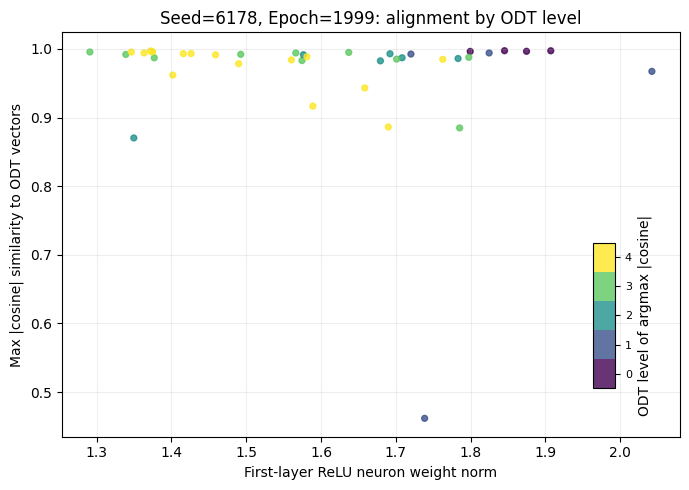

In [8]:
EPOCH = list(ckpts.keys())[1999]  # choose from available checkpoints

alignment, fig, ax = plot_first_layer_odt_alignment(
    state_dict=ckpts[EPOCH],
    tree=tree,
    depth=DEPTH,
    epoch=EPOCH,
    seed=SEED,
)
plt.show()

# Keep these names available for downstream scratch cells.
first_layer_wts = alignment["first_layer_wts"]
odt_wts = alignment["odt_wts"]
row_norms = alignment["row_norms"]
cos = alignment["cos"]
abs_cos = alignment["abs_cos"]
max_abs_cos = alignment["max_abs_cos"]
closest_odt = alignment["closest_odt"]
closest_odt_np = alignment["closest_odt_np"]
node_level = alignment["node_level"]

## Start/end metrics

This block computes start/end metrics for the selected seed.

In [7]:
if seed_result is None:
    raise ValueError("Run the training cell first to populate seed_result.")

rows = collect_start_end_metrics(seed_result)
metrics_table = pd.DataFrame(rows).sort_values(["timepoint"]).reset_index(drop=True)
display(metrics_table)

,timepoint,epoch,train_log_loss,test_error
0,end,1999,0.020148,0.045337
1,start,0,0.693147,0.500612
